## Notes

- Minimum 2 hectares parcels are ok, if near bigger parcels. They might consider using them anyway.
- For Dhar, up to 50m inter-khasra distance is okay.

In [1]:
INDIA_PROJECTED_CRS = "24378"

## Setup

In [2]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

In [4]:

def generate_colormap(N):
    arr = np.arange(N)/N
    N_up = int(math.ceil(N/7)*7)
    arr.resize(N_up)
    arr = arr.reshape(7,N_up//7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:,3].size
    a = n//2
    b = n-a
    for i in range(3):
        ret[0:n//2,i] *= np.arange(0.2,1,0.8/a)
    ret[n//2:,3] *= np.arange(1,0.3,-0.7/b)
    return ret

In [5]:
from gridsample.utils import create_ids, save_shapefiles
# from gridsample.mapping.plot import create_interactive_map

In [6]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
CLEANED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "01 Cleaned Khasras"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "03 Suggested Parcels" / "v2"

## Load cleaned khasras

In [7]:
# Dhar
dhar_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "dhar_cleaned_khasras.parquet")

In [8]:
# # Sagar
# sagar_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "sagar_cleaned_khasras.parquet")
# # filter to only the "PA" PAR_TYPE (since it looks like the barren land)
# sagar_gdf = sagar_gdf[sagar_gdf["PAR_TYPE"] == "PA"]

# 1. Cluster khasras into parcels

In [9]:
from clustering import (
    build_graph_from_gdf_with_distance_threshold,
    get_connected_components_by_distance_threshold,
)

In [10]:
LOCATION = "Dhar"
gdf = dhar_gdf.to_crs(INDIA_PROJECTED_CRS).reset_index(drop=True)[
    [
        "geometry",
        "khasra_id",
        "village_name",
    ]
]

In [11]:
# LOCATION = "Sagar"
# gdf = sagar_gdf.to_crs(INDIA_PROJECTED_CRS).reset_index(drop=True)[
#     [
#         "geometry",
#         "UNQID",
#         "village_name",
#     ]
# ]
# gdf.rename(columns={"UNQID": "khasra_id"}, inplace=True)

In [12]:
gdf["Khasra Area (ha)"] = gdf.area / 10_000

<Axes: >

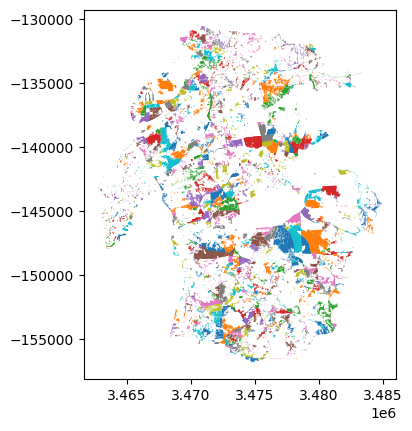

In [13]:
gdf.plot(column="khasra_id")

In [ ]:
# get graph, only considering neighbours within 200 meters
G = build_graph_from_gdf_with_distance_threshold(gdf, distance_threshold=200)

In [ ]:
f, ax = plt.subplots(2, 3, figsize=(12, 12))
ax = ax.flatten()

gdf_with_parcel_id = gdf.copy()
G_filtered_dict = {}

# plot original khasras
gdf.plot(ax=ax[0], column="khasra_id", cmap=ListedColormap(generate_colormap(len(gdf))))
ax[0].set_title("Original Khasras (Ungrouped)", fontsize=12)
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])

# xmin, xmax = 3_849_000, 3_854_000
# ymin, ymax = -22000, -15000
# ax[0].set_xlim(xmin, xmax)
# ax[0].set_ylim(ymin, ymax)

for i, distance_threshold in enumerate([5, 10, 25, 50, 100]):
    temp_parcel_id_col = f"parcel_id_{distance_threshold}m"

    cluster_labels_df, G_filtered_with_parcel_id = (
        get_connected_components_by_distance_threshold(
            G,
            distance_threshold,
            cluster_id_col_name="parcel_id",
            cluster_id_prefix="PARCEL_",
        )
    )
    G_filtered_dict[distance_threshold] = G_filtered_with_parcel_id
    cluster_labels_df.rename(columns={"parcel_id": temp_parcel_id_col}, inplace=True)
    # add parcel_id to gdf
    gdf_with_parcel_id = gdf_with_parcel_id.merge(
        cluster_labels_df, left_index=True, right_index=True, how="left"
    )

    N = len(gdf_with_parcel_id[temp_parcel_id_col].unique())

    i = i + 1  # start from second plot position
    gdf_with_parcel_id.plot(
        column=temp_parcel_id_col, ax=ax[i], cmap=ListedColormap(generate_colormap(N))
    )
    ax[i].set_title(
        f"Max Inter-Khasra Distance: {distance_threshold}m \nNumber of parcels formed: {N}",
        fontsize=12,
    )
    ax[i].set_xticklabels([])
    ax[i].set_yticklabels([])
    # set diplay limits
    # ax[i].set_xlim(xmin, xmax)
    # ax[i].set_ylim(ymin, ymax)

plt.tight_layout()
plt.savefig(
    OUTPUT_DATA_DIR / LOCATION / "parcels_w_different_thresholds.png", dpi=300
)

#### Do it for the decided threshold

In [ ]:
distance_threshold = 10

In [ ]:
cluster_labels_df, G_filtered_with_parcel_id = (
    get_connected_components_by_distance_threshold(
        G,
        distance_threshold,
        cluster_id_col_name="parcel_id",
        cluster_id_prefix="PARCEL_",
    )
)
G_filtered_dict[distance_threshold] = G_filtered_with_parcel_id

In [ ]:
# add parcel_id to gdf
gdf_with_parcel_id = gdf.merge(
    cluster_labels_df, left_index=True, right_index=True, how="left"
)

In [ ]:
gdf_with_parcel_id

In [ ]:
# manually combine PARCEL_01 and PARCEL_34
# gdf_with_parcel_id.loc[gdf_with_parcel_id["parcel_id"] == "PARCEL_34", "parcel_id"] = "PARCEL_01"

In [ ]:
gdf_with_parcel_id.plot(
    column="parcel_id",
    cmap=ListedColormap(
        generate_colormap(len(gdf_with_parcel_id["parcel_id"].unique()))
    ),
)

In [ ]:
save_shapefiles(
    gdf_with_parcel_id.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Khasra Shapefiles",
    "khasras_with_parcel_id_initial",
    formats=["parquet", "kml", "csv"],
)

### Make parcel-level gdf

#### Functions

In [ ]:
def get_closest_parcels(gdf, parcel_id_col="parcel_id"):
    min_distances = []
    closest_ids = []
    for i in range(len(gdf)):
        geom = gdf.iloc[i].geometry
        other_geoms = gdf.drop(gdf.index[i])
        distances = other_geoms.geometry.apply(lambda x: geom.distance(x))
        min_distance = distances.min().round(2)
        closest_id = other_geoms.loc[distances.idxmin()][parcel_id_col]
        min_distances.append(min_distance)
        closest_ids.append(closest_id)
    return min_distances, closest_ids

In [ ]:
def get_intra_parcel_distance_stats(G_filtered, parcel_ids, parcel_id_col="parcel_id"):
    """
    Get the inter-khasra distance stats within each parcel.

    Parameters
    ----------
    G_filtered : nx.Graph
        The graph with the edges filtered by the distance threshold.
    parcel_ids : list
        The list of parcel_ids to get the distances for.

    Returns
    -------
    pd.DataFrame
        A DataFrame with the parcel_id and corresponding distance stats.
    """

    # helper function to get the edge weights of a parcel_id
    def get_edge_weights_by_parcel_id(G_filtered, parcel_id):
        selected_nodes = {
            n for n, d in G_filtered.nodes(data=True) if d.get(parcel_id_col) == parcel_id
        }
        subgraph = G_filtered.subgraph(selected_nodes)
        edge_weights = [d["weight"] for _, _, d in subgraph.edges(data=True)]
        return edge_weights

    distances_list = []
    for parcel_id in parcel_ids:
        distances = get_edge_weights_by_parcel_id(G_filtered, parcel_id)
        if len(distances) == 0:
            avg_distance = 0
            min_distance = 0
            percentile_25th_distance = 0
            percentile_50th_distance = 0
            percentile_75th_distace = 0
            max_distance = 0
        else:
            # avg
            avg_distance = np.mean(distances)
            # min 25% quartile, median, 75% quantile, max
            min_distance = np.min(distances)
            percentile_25th_distance = np.percentile(distances, 20)
            percentile_50th_distance = np.percentile(distances, 50)
            percentile_75th_distace = np.percentile(distances, 75)
            max_distance = np.max(distances)

        distances_list.append({
            parcel_id_col: parcel_id,
            "Inter-Khasra Distance Average (m)": avg_distance,
            "Inter-Khasra Distance Min (m)": min_distance,
            "Inter-Khasra Distance 25th Percentile (m)": percentile_25th_distance,
            "Inter-Khasra Distance Median (m)": percentile_50th_distance,
            "Inter-Khasra Distance 75th Percentile (m)": percentile_75th_distace,
            "Inter-Khasra Distance Max (m)": max_distance,
            "raw_distances": distances,
        })
    
    return pd.DataFrame(distances_list).round(2)

#### Code

In [ ]:
# Group by the cluster value and dissolve to make a new GeoDataFrame. Remove the DISCARDED khasras before this.
parcel_gdf = gdf_with_parcel_id.dissolve(by="parcel_id")
parcel_gdf = parcel_gdf.drop(columns=["khasra_id", "Khasra Area (ha)"])
parcel_gdf = parcel_gdf.reset_index()

In [ ]:
parcel_gdf.loc[:, "Original Parcel Area (ha)"] = parcel_gdf["geometry"].area / 10_000

In [ ]:
parcel_gdf.plot(column="parcel_id", cmap=ListedColormap(generate_colormap(len(parcel_gdf))))

In [ ]:
parcel_gdf.plot(column="Original Parcel Area (ha)", cmap="viridis", legend=True)

In [ ]:
# filter to only parcels larger than 50 hectares
min_parcel_area_ha = 50
filtered_parcel_gdf = parcel_gdf[parcel_gdf["Original Parcel Area (ha)"] > min_parcel_area_ha]

# relabel them to DISCARDED in the khasra gdf too
too_small_parcel_ids = parcel_gdf[parcel_gdf["Original Parcel Area (ha)"] < min_parcel_area_ha][
    "parcel_id"
].values
filtered_gdf_with_parcel_id = gdf_with_parcel_id.copy()
filtered_gdf_with_parcel_id.loc[
    filtered_gdf_with_parcel_id["parcel_id"].isin(too_small_parcel_ids), "parcel_id"
] = "DISCARDED"

In [ ]:
# add how many khasras are inside
khasra_counts_series = gdf_with_parcel_id.groupby("parcel_id")["khasra_id"].count()
filtered_parcel_gdf["Khasra Count"] = filtered_parcel_gdf["parcel_id"].map(khasra_counts_series)

# add the names of all khasras that fall inside each parcel as a list under khasra_ids
khasra_ids_series = gdf_with_parcel_id.groupby("parcel_id")["khasra_id"].apply(list).astype(str)
filtered_parcel_gdf["Khasra IDs"] = filtered_parcel_gdf["parcel_id"].map(khasra_ids_series)

In [ ]:
# Calculate minimum distances and closest parcel_ids
min_distances, closest_ids = get_closest_parcels(filtered_parcel_gdf, parcel_id_col="parcel_id")

# Add the results as new columns
filtered_parcel_gdf.loc[:, "Closest Parcel Distance (m)"] = min_distances
filtered_parcel_gdf.loc[:, "Closest Parcel ID"] = closest_ids

In [ ]:
intra_distances_df = get_intra_parcel_distance_stats(
    G_filtered_with_parcel_id,
    filtered_parcel_gdf["parcel_id"].unique(),
    parcel_id_col="parcel_id",
)

In [ ]:
filtered_parcel_gdf = filtered_parcel_gdf.join(
    intra_distances_df.set_index("parcel_id").drop(columns="raw_distances"),
    on="parcel_id",
)

In [ ]:
filtered_parcel_gdf = filtered_parcel_gdf.sort_values(by="Original Parcel Area (ha)", ascending=False)

In [ ]:
# drop if far and small...

In [ ]:
ax = parcel_gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
filtered_parcel_gdf.plot(ax=ax, column="parcel_id", legend=True, cmap=ListedColormap(generate_colormap(len(filtered_parcel_gdf))))

### Save parcel files

In [ ]:
save_shapefiles(
    filtered_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Parcel Shapefiles",
    "parcels_filtered",
    formats=["parquet", "kml", "csv"],
)

# 2. Add unusable layers

## Water

In [ ]:
# water_bodies_gdf = gpd.read_file(RAW_DATA_DIR / "water" / "DWA Waterbodies Ph1 for Madhya Pradesh.geojson")
# water_bodies_gdf = water_bodies_gdf.to_crs(INDIA_PROJECTED_CRS)

# # get cutout of the water shapes that overlap parcels
# water_overlap_gdf = gpd.overlay(
#     water_bodies_gdf, filtered_parcel_gdf, how="intersection"
# )
# water_overlap_gdf = water_overlap_gdf.dissolve(by="parcel_id").reset_index()

In [ ]:
# water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
# water_unusable_area_df = water_overlap_gdf[["parcel_id", "Unusable Area - Water (ha)"]]

In [ ]:
# ax = filtered_parcel_gdf.plot(figsize=(10, 10), color="brown")
# water_overlap_gdf.plot(ax=ax)

## Buildings

In [ ]:
from s2cell.s2cell import lat_lon_to_cell_id
import boto3
import shapely

#### Download rooftop data

Get the ID of the level 6 S2 Cell that this area sits inside

In [ ]:
s2_ids = []

for index, row in filtered_parcel_gdf.to_crs(4326).iterrows():
    lat = row["geometry"].centroid.y
    lon = row["geometry"].centroid.x
    s2_cell_id = lat_lon_to_cell_id(lat=lat, lon=lon, level=6)
        
    s2_ids.append(s2_cell_id)

s2_ids = list(set(s2_ids))


Download closest S2 cell shapefile from https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/

In [ ]:
for s2_cell_id in s2_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print("File already exists")
    else:
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        s3.download_file(
            "vida",
            f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/{s2_cell_id}.parquet",
            str(s2_rooftops_path),
        )
        print("File downloaded.")

#### Load and process rooftop data

In [ ]:
rooftop_gdf_list = []
for s2_cell_id in s2_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
    rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
    rooftop_gdf_list.append(rooftop_gdf)

rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
rooftop_gdf = rooftop_gdf[
    [
        "bf_source",
        "confidence",
        "area_in_meters",
        "geometry",
    ]
]

rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")
rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

### Filter to only rooftops that overlap the parcels

In [ ]:
subset_rooftops_gdf = rooftop_gdf.sjoin(
    filtered_parcel_gdf, how="inner", predicate="intersects"
).drop(columns=["index_right"])
subset_rooftops_gdf.drop(
    columns=filtered_parcel_gdf.columns.drop("geometry"), inplace=True
)

In [ ]:
buffer = 25
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(
    buffered_rooftops_gdf, filtered_parcel_gdf, how="intersection"
)

### Export rooftops, manually draw settlement boundaries, and load in

In [ ]:
save_shapefiles(
    buildings_overlap_gdf.to_crs(epsg=4326)[
        [
            "parcel_id",
            "geometry",
        ]
    ],
    OUTPUT_DATA_DIR / LOCATION / "settlements",
    "buildings",
    formats=["kml"],
)

In [ ]:
# AUTOMATIC

# cluster rooftops to find densest areas
from sklearn.cluster import HDBSCAN

dbscan = HDBSCAN(min_cluster_size=2, cluster_selection_epsilon=50, n_jobs=-1)
building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = dbscan.fit_predict(X)
buildings_overlap_gdf["building_cluster_id"] = building_cluster_ids

In [ ]:
# add settlement_id to buildings_overlap_gdf
rogue_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["building_cluster_id"] == -1
]
settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["building_cluster_id"] != -1
]

In [ ]:
# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="building_cluster_id")
settlements_gdf = settlements_gdf.reset_index()
settlements_gdf.geometry = settlements_gdf.convex_hull

settlements_gdf.plot()

In [ ]:
# # MANUAL

# # load KML
# settlements_gdf = gpd.read_file(
#     OUTPUT_DATA_DIR / "Sagar" / "settlements" / "settlements.kml", driver="KML"
# )
# # drop the z dimension from the geometries
# settlements_gdf.geometry = settlements_gdf.geometry.apply(
#     lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
# )
# settlements_gdf = settlements_gdf.to_crs(INDIA_PROJECTED_CRS)
# settlements_gdf.rename(columns={"Name": "settlement_id"}, inplace=True)

# # get cutout of the buffered building shapes that overlap parcels
# settlements_gdf = gpd.overlay(settlements_gdf, filtered_parcel_gdf, how="intersection")
# settlements_gdf = settlements_gdf[["parcel_id", "settlement_id", "geometry"]]


# # add settlement_id to buildings_overlap_gdf
# buildings_labeled_gdf = buildings_overlap_gdf.sjoin(
#     settlements_gdf[["settlement_id", "geometry"]], how="left", predicate="intersects"
# ).drop(columns=["index_right"])

# rogue_buildings_gdf = buildings_labeled_gdf[buildings_labeled_gdf["settlement_id"].isna()]
# settlement_buildings_gdf = buildings_labeled_gdf[~buildings_labeled_gdf["settlement_id"].isna()]

In [ ]:
# plot
ax = filtered_parcel_gdf.plot(figsize=(10, 10))
settlements_gdf.plot(ax=ax, color="black")
buildings_overlap_gdf.plot(ax=ax, color="yellow")

In [ ]:
rogue_buildings_overlap_gdf = rogue_buildings_gdf.dissolve(by="parcel_id").reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(by="parcel_id").reset_index()

In [ ]:
rogue_buildings_overlap_gdf["Unusable Area - Rogue Buildings (ha)"] = rogue_buildings_gdf.area / 10_000
rogue_buildings_unusable_area_df = rogue_buildings_overlap_gdf[["parcel_id", "Unusable Area - Rogue Buildings (ha)"]]

In [ ]:
settlements_overlap_gdf = settlements_gdf.dissolve(by="parcel_id").reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = settlements_overlap_gdf.area / 10_000
settlements_unusable_area_df = settlements_overlap_gdf[["parcel_id", "Unusable Area - Settlements (ha)"]]

## Landcover (Cropland, Water)

### Landcover

In [ ]:
# for TIFF files
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape

In [ ]:
def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [ ]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

In [ ]:
masked_landcover_data, masked_transform = rasterio.mask.mask(src, [filtered_parcel_gdf.to_crs(4326).unary_union], crop=True)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [ ]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)
landcover_class_value_dict

### Cropland

In [ ]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [ ]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(
    cropland_shapes_gdf, filtered_parcel_gdf, how="intersection"
)
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(by="parcel_id").reset_index()

In [ ]:
cropland_overlap_gdf["Unusable Area - Cropland (ha)"] = cropland_overlap_gdf.area / 10_000
cropland_unusable_area_df = cropland_overlap_gdf[["parcel_id", "Unusable Area - Cropland (ha)"]]

### Water

In [ ]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [ ]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(
    water_shapes_gdf, filtered_parcel_gdf, how="intersection"
)
water_overlap_gdf = water_overlap_gdf.dissolve(by="parcel_id").reset_index()

In [ ]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[["parcel_id", "Unusable Area - Water (ha)"]]

## Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

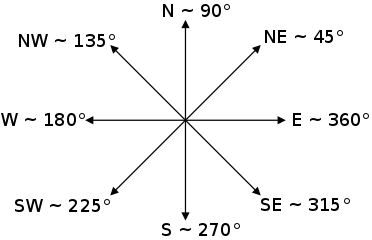

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

#### Load slope data

In [ ]:
from pydem.dem_processing import DEMProcessor

In [ ]:
def get_steep_shapes(dem_filename):
    print(f"Processing {dem_filename}...")
    dem_filepath = RAW_DATA_DIR / "elevation" / f"{dem_filename}.tif"
    dem_proc = DEMProcessor(dem_filepath)
    transform = dem_proc.transform  # need this transform later

    # # calculate slope and aspect and save to file
    # mag, aspect = dem_proc.calc_slopes_directions()
    # np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy", mag)
    # np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy", aspect)

    # OR if precomputed, load files
    slope_pydem = np.load(RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy")
    aspect_pydem = np.load(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy")

    # convert from radians to degrees
    aspect = np.degrees(aspect_pydem)
    slope = np.degrees(slope_pydem)

    # Display slope and aspect
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 6))
    # slope vis
    ax1.imshow(slope)
    ax1.set_title(f"{dem_filename} - Slope")
    ax2.hist(slope.flatten(), bins=100)
    ax2.set_title("Slope Histogram")
    # aspect vis
    ax3.imshow(aspect)
    ax3.set_title(f"{dem_filename} - Aspect")
    ax4.hist(aspect.flatten(), bins=100)
    ax4.set_title("Aspect Histogram")
    plt.tight_layout()
    plt.show()

    # set all values below 0 to 0
    aspect[aspect < 0] = 0
    slope[slope < 0] = 0

    # filter to only aspects that are between NE and NW azimuth around north and 7 degrees or more
    slope_mask = np.where((aspect >= 45) & (aspect < 135) & (slope > 7), True, False)

    # Plot the mask with a binary colormap and correct axes
    x_min = transform[2]
    x_max = x_min + transform[0] * slope_mask.shape[1]
    y_max = transform[5]
    y_min = y_max + transform[4] * slope_mask.shape[0]
    plt.imshow(slope_mask, extent=[x_min, x_max, y_min, y_max], cmap="binary")
    plt.colorbar(label="Aspect Mask", ax=ax)
    plt.title("Aspect Mask")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

    # Extract vector shapes and make a GeoDataFrame
    print("Extracting vector shapes...")
    vector_shapes = [
        {"geometry": shape(geom)}
        for geom, class_value in shapes(slope, mask=slope_mask, transform=transform)
    ]
    slope_shapes_gdf = gpd.GeoDataFrame(vector_shapes)
    slope_shapes_gdf = slope_shapes_gdf.set_crs(4326).to_crs(INDIA_PROJECTED_CRS)

    return slope_shapes_gdf

In [ ]:
dem_filenames = ["cdnf43i", "cdnf43j"]

steep_shapes_gdf_list = []
for dem_filename in dem_filenames:
    steep_shapes_gdf = get_steep_shapes(dem_filename)
    steep_shapes_gdf_list.append(steep_shapes_gdf)

In [ ]:
slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)

In [ ]:
slope_overlap_gdf = gpd.overlay(
    slope_shapes_gdf, filtered_parcel_gdf, how="intersection", keep_geom_type=False
)
slope_overlap_gdf = slope_overlap_gdf.dissolve(by="parcel_id").reset_index()

In [ ]:
slope_overlap_gdf.plot(column="parcel_id")

In [ ]:
slope_overlap_gdf["Unusable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[["parcel_id", "Unusable Area - Slope (ha)"]]

# Final Calculations

## Plots

In [ ]:
import matplotlib.patches as mpatches

In [ ]:
# CHOSEN_PARCEL_ID = "PARCEL_0005"
parcel_id_list = list(filtered_parcel_gdf["parcel_id"].unique())
for CHOSEN_PARCEL_ID in parcel_id_list:
    FOLDER_PATH = OUTPUT_DATA_DIR / LOCATION / "Chosen Parcels" / CHOSEN_PARCEL_ID
    FOLDER_PATH.mkdir(parents=True, exist_ok=True)


    # Plotting the histogram of intra-distances
    subset_intra_distances_df = intra_distances_df[
        intra_distances_df["parcel_id"] == CHOSEN_PARCEL_ID
    ]

    f, ax = plt.subplots(1, 1, figsize=(8, 6))
    subset_intra_distances_df["raw_distances"].hist(
        ax=ax, bins=25, color="skyblue", edgecolor="black"
    )

    # add lines for average and 75% percentile
    avg_distance = subset_intra_distances_df["Inter-Khasra Distance Average (m)"].values[0]
    percentile_75th_distance = subset_intra_distances_df["Inter-Khasra Distance 75th Percentile (m)"].values[0]

    ax.axvline(avg_distance, color="brown", linestyle="--", label=f"Average: {avg_distance}m")
    ax.axvline(percentile_75th_distance, color="darkgreen", linestyle="--", label=f"75th Percentile: {percentile_75th_distance}m")

    ax.legend()
    # ax.set_title(f"Inter-Khasra Distances within {CHOSEN_PARCEL_ID}", fontsize=14)
    ax.set_xlabel("Distance to Neighbouring Khasra", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.savefig(FOLDER_PATH / "intra_distances_histogram.png", dpi=300)
    plt.show()


    ax = gdf_with_parcel_id[gdf_with_parcel_id["parcel_id"] == CHOSEN_PARCEL_ID].plot(
        column="khasra_id",
        cmap=ListedColormap(
            generate_colormap(len(gdf_with_parcel_id["khasra_id"].unique()))
        ),
        figsize=(8, 8),
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # add a 1km line to show scale on the plot
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.plot([xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
    ax.plot([xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
    ax.plot([xmax - 550, xmax - 450], [ymin + 130, ymin + 130], color="white", linewidth=7, linestyle="-")
    ax.text(xmax - 500, ymin + 100, "1km", fontsize=6, ha="center")

    # ax.set_title(f"Khasras in {CHOSEN_PARCEL_ID}", fontsize=12)

    plt.tight_layout()
    plt.savefig(FOLDER_PATH / "khasras.png", dpi=300)


    ax = gdf_with_parcel_id[gdf_with_parcel_id["parcel_id"] == CHOSEN_PARCEL_ID].plot(
        color="brown",
        label="Original Parcel",
        figsize=(10, 10),
    )
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # add a 1km line to show scale on the plot
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    ax.plot([xmax - 1000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
    ax.plot([xmax - 1000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
    ax.plot(
        [xmax - 550, xmax - 450],
        [ymin + 130, ymin + 130],
        color="white",
        linewidth=7,
        linestyle="-",
    )
    ax.text(xmax - 500, ymin + 100, "1km", fontsize=6, ha="center")

    handles = []
    for i in range(5):
        if i >= 0:
            buildings_overlap_gdf[
                buildings_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID
            ].plot(ax=ax, color="yellow", label="Buildings + 25m buffer")
            LAYERS = "Buildings"
            handles.append(mpatches.Patch(color="yellow", label="Buildings + 25m buffer"))

        if i >= 1:
            settlements_overlap_gdf[
                settlements_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID
            ].plot(ax=ax, color="black", alpha=0.5, label="Settlements")
            LAYERS = "Buildings, Settlements"
            handles.append(mpatches.Patch(color="black", label="Settlements"))

        if i >= 2:
            water_overlap_gdf[water_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(
                ax=ax, color="C0", label="Water"
            )
            LAYERS = "Buildings, Settlements, Water"
            handles.append(mpatches.Patch(color="C0", label="Water"))

        if i >= 3:
            cropland_overlap_gdf[
                cropland_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID
            ].plot(ax=ax, color="green", label="Cropland")
            LAYERS = "Buildings, Settlements, Water, Cropland"
            handles.append(mpatches.Patch(color="green", label="Cropland"))

        if i >= 4:
            slope_overlap_gdf[slope_overlap_gdf["parcel_id"] == CHOSEN_PARCEL_ID].plot(
                ax=ax, color="grey", alpha=0.8, label="Slopes > 7 deg"
            )
            LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
            handles.append(
                mpatches.Patch(color="grey", label="Slope > 7° between NE and NW")
            )

        ax.legend(handles=handles, loc="upper left")
        # ax.set_title(f"{CHOSEN_PARCEL_ID} \n+ {LAYERS}", fontsize=12)
        plt.tight_layout()
        plt.savefig(
            FOLDER_PATH / f"Layers - {LAYERS}.png",
            dpi=300,
        )

        handles = []

## Cutout

In [ ]:
usable_filtered_parcel_gdf = filtered_parcel_gdf.copy()

# cut out settlements
usable_filtered_parcel_gdf = gpd.overlay(
    usable_filtered_parcel_gdf,
    settlements_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out rogue buildings
usable_filtered_parcel_gdf = gpd.overlay(
    usable_filtered_parcel_gdf,
    rogue_buildings_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out water
usable_filtered_parcel_gdf = gpd.overlay(
    usable_filtered_parcel_gdf,
    water_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out cropland
usable_filtered_parcel_gdf = gpd.overlay(
    usable_filtered_parcel_gdf,
    cropland_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out slopes
usable_filtered_parcel_gdf = gpd.overlay(
    usable_filtered_parcel_gdf,
    slope_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

In [ ]:
usable_filtered_parcel_gdf["Usable Area (ha)"] = usable_filtered_parcel_gdf.area / 10_000
usable_filtered_parcel_gdf["Unsable Area Total (ha)"] = (
    usable_filtered_parcel_gdf["Original Parcel Area (ha)"]
    - usable_filtered_parcel_gdf["Usable Area (ha)"]
)

In [ ]:
# add unusable areas
all_unusable_area_cols_df = settlements_unusable_area_df.merge(rogue_buildings_unusable_area_df, on="parcel_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(water_unusable_area_df, on="parcel_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(cropland_unusable_area_df, on="parcel_id", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(slope_unusable_area_df, on="parcel_id", how="outer").fillna(0)

usable_filtered_parcel_gdf = usable_filtered_parcel_gdf.merge(all_unusable_area_cols_df, on="parcel_id", how="left").fillna(0)

In [ ]:
usable_filtered_parcel_gdf["village_name"] = usable_filtered_parcel_gdf["village_name"].astype(str)

save_shapefiles(
    usable_filtered_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / LOCATION / "Parcel Shapefiles",
    "parcels_filtered_usable",
    formats=["parquet", "kml", "csv"],
)

In [ ]:
# save all unusable layes as separate KML files
save_shapefiles(
    water_overlap_gdf.to_crs(epsg=4326)[
        [
            "parcel_id",
            "geometry",
            "Unusable Area - Water (ha)",
        ]
    ],
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf.to_crs(epsg=4326)[
        [
            "parcel_id",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ]
    ],
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

save_shapefiles(
    buildings_overlap_gdf.to_crs(epsg=4326)[
        [
            "parcel_id",
            "geometry",
            # "Unusable Area - Rogue Buildings (ha)",
        ]
    ],
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "buildings",
    formats=["kml"],
)

save_shapefiles(
    cropland_overlap_gdf.to_crs(epsg=4326)[
        [
            "parcel_id",
            "geometry",
            "Unusable Area - Cropland (ha)",
        ]
    ],
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "cropland",
    formats=["kml"],
)

save_shapefiles(
    slope_overlap_gdf.to_crs(epsg=4326)[
        [
            "parcel_id",
            "geometry",
            "Unusable Area - Slope (ha)",
        ]
    ],
    OUTPUT_DATA_DIR / LOCATION / "Unusable Layers",
    "slopes",
    formats=["kml"],
)

# Scraps

In [ ]:
# start = 270
# end = 360
# mask = (aspect > start) & (aspect < end)

# # Calculate the extent
# x_min = transform[2]
# x_max = x_min + transform[0] * mask.shape[1]
# y_max = transform[5]
# y_min = y_max + transform[4] * mask.shape[0]

# # Plot the mask with a binary colormap and correct axes
# plt.imshow(mask, cmap="binary", extent=[x_min, x_max, y_min, y_max])
# plt.colorbar(label="Aspect Mask")
# plt.title("Aspect Mask")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.show()

In [ ]:
# def build_graph_from_gdf(gdf):
#     """
#     Build a graph from a GeoDataFrame where the nodes are the index of the GeoDataFrame
#     and the edges are the distance between the geometries.

#     Parameters
#     ----------
#     gdf : GeoDataFrame
#         The GeoDataFrame to build the graph from.

#     Returns
#     -------
#     nx.Graph
#         The graph with the distances as the edge attribute.
#     """

#     gdf_index = list(gdf.index)
#     G = nx.Graph()
#     for i, geom1 in enumerate(gdf.geometry):
#         for j, geom2 in enumerate(gdf.geometry):
#             if i <= j:
#                 distance = geom1.distance(geom2)
#                 G.add_edge(gdf_index[i], gdf_index[j], distance=distance)

#     print(
#         f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges."
#     )
#     return G

In [ ]:
# def calculate_distance_matrix_old(gdf):
#     distances = gdf.geometry.apply(lambda geom1: gdf.geometry.distance(geom1))
#     return distances.to_numpy()

In [ ]:
# def calculate_distance_matrix_upper(gdf):
#     n = len(gdf)
#     distance_matrix_upper = np.full((n, n), np.nan)
#     for i, geom1 in enumerate(gdf.geometry):
#         for j, geom2 in enumerate(gdf.geometry):
#             if i < j:
#                 distance = geom1.distance(geom2)
#                 distance_matrix_upper[i, j] = distance
#                 distance_matrix_upper[j, i] = distance
#             if i == j:
#                 distance_matrix_upper[i, j] = 0
#     return distance_matrix_upper

In [ ]:
# def cluster_adjacent_shapes_old(gdf, distance_threshold):
#     gdf_index = gdf.index

#     # Step 2: Create a distance-filtered spatial graph
#     G = nx.Graph()
#     for i, geom1 in enumerate(gdf.geometry):
#         for j, geom2 in enumerate(gdf.geometry):
#             if i != j:
#                 distance = geom1.distance(geom2)
#                 if distance < distance_threshold:
#                     # this means far away nodes don't actually ever get added to the graph
#                     G.add_edge(i, j, distance=distance)

#     # Step 3: Find connected components
#     connected_components = list(nx.connected_components(G))

#     # Step 4: Convert the connected components to a list of labels that matches the input data
#     data = []
#     for cluster_id, value_set in enumerate(connected_components):
#         for value in value_set:
#             data.append((value, cluster_id))

#     df = pd.DataFrame(data, columns=["index", "cluster"])
#     df.set_index("index", inplace=True)

#     # make index of df the same as gdf and assign any missing values as -1
#     cluster_labels = df.reindex(gdf_index)["cluster"].fillna(-1).astype(int)

#     return cluster_labels, G, connected_components

In [ ]:
# sagar_gdf[sagar_gdf["khasra_id"] == "17677985"].geometry.values[0].distance(
#     sagar_gdf[sagar_gdf["khasra_id"] == "17677984"].geometry.values[0]
# )

In [ ]:
# sagar_gdf_4326 = sagar_gdf.to_crs("4326")
# sagar_gdf_4326["Lat"] = sagar_gdf_4326.centroid.y
# sagar_gdf_4326["Lon"] = sagar_gdf_4326.centroid.x
# create_interactive_map(sagar_gdf_4326, point_id_col="khasra_id", zoom_start=12)

In [ ]:
# from sklearn.cluster import HDBSCAN
# clusters = HDBSCAN(min_cluster_size=2, metric="precomputed", n_jobs=-1).fit(dist_matrix)
# gdf['clustering_dbscan'] = clusters.labels_
# gdf.plot(column='clustering_dbscan', legend=True)